# Testing and Debugging

In this tutorial, we will dive deeper into Workbench tools that help you debug your quantum programs and write tests for them.

Earlier we've seen that one of the main purposes of [quantum simulators](./Simulating-WB-Programs.ipynb) is running small instances of quantum programs and using the results to verify that they produce correct results. However, limiting ourselves to only program results (that is, values produced by measurements) makes testing code very challenging.

In this tutorial, we will go over the additional APIs provided by Workbench to facilitate testing quantum programs. These APIs allow you to access the internal state of the simulators and get in-depth information about program behavior. They are impossible to use when running the program on a real quantum device, but having access to them while developing the program and testing it on a simulator is already a huge step forward compared to just using measurement outcomes!

## Drawing the circuit

Drawing a circuit representation of the program using the `draw` method of the QPU object is commonly used to represent the visual structure of small programs. In fact, these tutorials use the `draw` method all the time to show the circuit generated by the program side by side with the program itself!

> Using the `draw` method of the QPU object requires that this object is initialized with `>>buffer>>` or `>>capture>>` in the filter pipeline. Otherwise, there will be no instructions to draw.

The following code snippet illustrates the use of the `draw` method to draw a simple state preparation circuit.

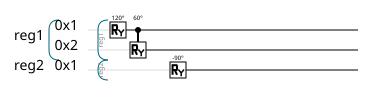

In [1]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3)
reg1 = Qubits(2, "reg1", qpu)
reg2 = Qubits(1, "reg2", qpu)

reg1[0].ry(2 * 60)
reg1[1].ry(2 * 30, cond=reg1[0])
qpu.nop()
reg2.ry(-2 * 45)

qpu.nop(repeat=9)
qpu.draw()

## Getting the quantum state 

Workbench provides a variety of methods to get the state vector that describes the state of the whole QPU or a Qubits register:

* The `pull_state` method of both QPU and Qubits objects returns the list of complex amplitudes that describe the state of this object.

  > The bit-vector simulator implementation of this method returns a string containing the bitstring representation of the current state of the QPU or Qubits object. Since the bit-vector simulator will only ever exist in one of the many states (as there is no superposition), this is a more compact representation.

* The `print_state_vector` method of both QPU and Qubits objects prints the list of basis states with non-zero amplitudes and the amplitudes associated with each of the basis states.

  > This method is implemented for both the state vector simulator and the bit-vector simulator. In particular for the bit-vector simulator, this method is able to scale as the size of the state grows to many more qubits than the state vector simulator since the bit-vector simulator only simulates one state at a time.

* The `print_probabilities` method of both QPU and Qubits objects prints the list of basis states with non-zero probabilities and the probabilities associated with each of the basis states.

  > This method is implemented for both the state vector simulator and the bit-vector simulator. In the case of the bit-vector simulator, it will have the same output as `print_state_vector`.


The following code snippet shows the use of these methods. It prepares a two-qubit register `reg1` in the state $\tfrac12 |00\rangle + \tfrac{\sqrt3}2 |1\rangle \otimes (\tfrac{\sqrt3}2 |0\rangle + \tfrac12|1\rangle) $ and a single-qubit register `reg2` in the state $\tfrac1{\sqrt2}(|0\rangle + |1\rangle)$ and shows the outputs of the `print_state_vector` and `print_probabilities` methods and the return values of the `pull_state` method for the whole QPU and for the individual registers.

In [2]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3)
reg1 = Qubits(2, "reg1", qpu)
reg2 = Qubits(1, "reg2", qpu)

reg1[0].ry(2 * 60)
reg1[1].ry(2 * 30, cond=reg1[0])
reg2.ry(-2 * 45)

print("QPU state vector")
qpu.print_state_vector()
print("QPU probabilities")
qpu.print_probabilities()
print(qpu.pull_state())

print("   reg1 state vector")
reg1.print_state_vector()
print("   reg1 probabilities")
reg1.print_probabilities()
print(reg1.pull_state())

print("   reg2 state vector")
reg2.print_state_vector()
print("   reg2 probabilities")
reg2.print_probabilities()
print(reg2.pull_state())

QPU state vector
|reg1|reg2>
|0|0>    0.353553+0.000000j
|0|1>    -0.353553+0.000000j
|1|0>    0.530330+0.000000j
|1|1>    -0.530330+0.000000j
|3|0>    0.306186+0.000000j
|3|1>    -0.306186+0.000000j
QPU probabilities
|reg1|reg2>
|0|0>    0.125000
|0|1>    0.125000
|1|0>    0.281250
|1|1>    0.281250
|3|0>    0.093750
|3|1>    0.093750
[ 0.35355339+0.j  0.53033009+0.j  0.        +0.j  0.30618622+0.j
 -0.35355339+0.j -0.53033009+0.j  0.        +0.j -0.30618622+0.j]
   reg1 state vector
|reg1>
|0>    0.500000+0.000000j
|1>    0.750000+0.000000j
|3>    0.433013+0.000000j
   reg1 probabilities
|reg1>
|0>    0.250000
|1>    0.562500
|3>    0.187500
[0.5      +0.j 0.75     +0.j 0.       +0.j 0.4330127+0.j]
   reg2 state vector
|reg2>
|0>    0.707107+0.000000j
|1>    -0.707107+0.000000j
   reg2 probabilities
|reg2>
|0>    0.500000
|1>    0.500000
[ 0.70710678+0.j -0.70710678+0.j]


### Getting the quantum state of typed registers

If you are using [quantum arithmetic data types](./Quantum-Arithmetic-Data-Types.ipynb) instead of raw Qubits registers, printing their state using `print_state_vector` and `print_probabilities` will reflect their data type.

In the following example, we instantiate a two-qubit `QInt` and a two-qubit `QFixed` registers. After applying a Hadamard gate to each qubit, we can use `print_state_vector` on the QPU or individually on each register.  In either case, the basis states will show appropriate signed integer and signed fixed point representations rather than the unsigned integer representation used for raw Qubits type.

In [3]:
from psiqdk.workbench import QFixed, QInt, QPU

qpu = QPU(num_qubits=4)
signed = QInt(2, "signed_reg", qpu)
fixed_point = QFixed(2, 2, "fixed_point_reg", qpu)

signed.had()
fixed_point.had()

print("Signed integer state vector")
signed.print_state_vector()
print("Signed fixed point state vector")
_ = fixed_point.print_state_vector()

Signed integer state vector
|signed_reg>
|-2>    0.500000+0.000000j
|-1>    0.500000+0.000000j
|0>    0.500000+0.000000j
|1>    0.500000+0.000000j
Signed fixed point state vector
|fixed_point_reg>
|-0.50>    0.500000+0.000000j
|-0.25>    0.500000+0.000000j
|0.000>    0.500000+0.000000j
|0.250>    0.500000+0.000000j


To get the unsigned integer representations of type registers, you can pass the `with_qreg_types=False` argument to `print_state_vector` or `print_probabilities`.

In [4]:
from psiqdk.workbench import QInt, QPU

qpu = QPU(num_qubits=2)
signed = QInt(2, "signed_reg", qpu)

signed.had()

print("QPU state vector")
_ = qpu.print_state_vector(with_qreg_types=False)

QPU state vector
|signed_reg>
|0>    0.500000+0.000000j
|1>    0.500000+0.000000j
|2>    0.500000+0.000000j
|3>    0.500000+0.000000j


### Getting entangled quantum states

Below we have two registers, a two-qubit register `reg1` and a one-qubit register `reg2`. The first is initialized with a state vector $0.36|00\rangle + 0.48|01\rangle + 0.48|10\rangle + 0.64|11\rangle$. The second register is put into an equal superposition between state $|0\rangle$ and state $|1\rangle$ if `reg1` is in the state $|11\rangle$.  Together, this results in a combined state vector in which `reg1` and `reg2` are entangled with one another: 

$$(0.36|00\rangle + 0.48|01\rangle + 0.48|10\rangle)_{reg1} \otimes |0\rangle_{reg2}$$
$$+0.452548|11\rangle_{reg1} \otimes (|0\rangle + |1\rangle)_{reg2}$$

In [5]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3)

reg1 = Qubits(2, "reg1", qpu=qpu)
reg2 = Qubits(1, "reg2", qpu=qpu)

reg1.push_state([0.36, 0.48, 0.48, 0.64])
reg2.ry(90, reg1)

_ = qpu.print_state_vector()

|reg1|reg2>
|0|0>    0.360000+0.000000j
|1|0>    0.480000+0.000000j
|2|0>    0.480000+0.000000j
|3|0>    0.452548+0.000000j
|3|1>    0.452548+0.000000j


When we want to print the state vector of individual registers using `print_state_vector`, there is a complicating factor when they are entangled with other qubits. Their state can not be cleanly separated from the state of other qubits. By default, `print_state_vector` recognizes when the register is entangled with another register. In this case, Workbench identifies which other registers are entangled with the requested register. Then it displays the full state vector for the entangled set of registers.

For this example, if we try to print the state vector of `reg1` or `reg2` separately, we get the same two-register state vector, since the system is small.

Entanglement detection and state vector expansion is done whenever `show_entangled=True` is passed as an argument to `print_state_vector`, which is the default.

In [6]:
print("reg1 with entangled components")
reg1.print_state_vector()
print("reg2 with entangled components")
_ = reg2.print_state_vector()

reg1 with entangled components
printing info for ['reg1']
entangled_items=['reg1', 'reg2']
|reg1|reg2>
|0|0>    0.360000+0.000000j
|1|0>    0.480000+0.000000j
|2|0>    0.480000+0.000000j
|3|0>    0.452548+0.000000j
|3|1>    0.452548+0.000000j
reg2 with entangled components
printing info for ['reg2']
entangled_items=['reg1', 'reg2']
|reg1|reg2>
|0|0>    0.360000+0.000000j
|1|0>    0.480000+0.000000j
|2|0>    0.480000+0.000000j
|3|0>    0.452548+0.000000j
|3|1>    0.452548+0.000000j


There may be occasions when the full entangled state is more complicated and you may want to isolate a particular register without showing the registers it is entangled with. This can be done by using `print_state_vector` with `show_entangled=False`. When the state of an entangled register is isolated and printed, we choose the highest probability state to display, as described below.

Below we once again have our example registers, a two-qubit register `reg1` and a one-qubit register `reg2` entangled in the following state vector: 

$$(0.36|00\rangle + 0.48|10\rangle + 0.48|10\rangle)_{reg1} \otimes |0\rangle_{reg2}$$
$$+0.452548|11\rangle_{reg1} \otimes (|0\rangle + |1\rangle)_{reg2}$$

In [7]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3)

reg1 = Qubits(2, "reg1", qpu=qpu)
reg2 = Qubits(1, "reg2", qpu=qpu)

reg1.push_state([0.36, 0.48, 0.48, 0.64])
reg2.ry(90, reg1)

_ = qpu.print_state_vector()

|reg1|reg2>
|0|0>    0.360000+0.000000j
|1|0>    0.480000+0.000000j
|2|0>    0.480000+0.000000j
|3|0>    0.452548+0.000000j
|3|1>    0.452548+0.000000j


For `reg1`, we want to isolate the superposition state that will have the highest probability if the qubits that `reg1` is entangled with are measured. In this example, there are two cases or "environments," one where `reg2` is measured in the state $|0\rangle$ and one where `reg2` is measured in the state $|1\rangle$.  For each environment, we determine a state vector for `reg1`, and its probability of occurring when `reg2` is measured.

What happens if we were to measure `reg2`? In this case, we can rewrite our state vector in a normalized form:

$$(0.403705|00\rangle + 0.538274|01\rangle + 0.538274|10\rangle + 0.507489|11\rangle)_{reg1} \otimes 0.8916 |0\rangle_{reg2}$$
$$+ 0.452548|11\rangle_{reg1} \otimes |1\rangle_{reg2}$$

We can see that we have $0.8916^2 = 0.795$ (79.5%) probability of measuring `reg2` in the state $|0\rangle$, which means `reg1` is in the state
 
$$0.403705|00\rangle + 0.538274|01\rangle + 0.538274|10\rangle + 0.507489|11\rangle$$
 
We also see that there is $0.452548^2 = 0.205$ (20.5%) probability of measuring `reg2` in the state $|1\rangle$, which means `reg1` in the state $|11\rangle$.  So, we display the normalized state vector for `reg1` when `reg2` is measured to be in the state $|0\rangle$ as it is more probable.

However, there is a warning informing you that this is not the full picture.

In [8]:
import warnings

with warnings.catch_warnings(record=True) as caught_warnings:
    reg1.print_state_vector(show_entangled=False)
    print(f"Warning: {caught_warnings[0].message}")

|reg1>
|0>    0.403705+0.000000j
|1>    0.538274+0.000000j
|2>    0.538274+0.000000j
|3>    0.507489+0.000000j


For `reg2`, we instead want to isolate the superposition state with the highest probability when `reg1` is measured. In this case, there are four environments, when `reg1` is in $|00\rangle$, $|01\rangle$, $|10\rangle$ or $|11\rangle$ state.

For each environment, we determine a state vector for `reg2`, and its probability:

$$ 0.36|00\rangle_{reg1} \otimes |0\rangle_{reg2} + 0.48|01\rangle_{reg1} \otimes |0\rangle_{reg2} + 0.48|10\rangle_{reg1} \otimes |0\rangle_{reg2}$$
$$+0.64 |11\rangle_{reg1} \otimes (0.707107|0\rangle + 0.707107|1\rangle)_{reg2}$$

- `reg1` is measured to be in state $|00\rangle$ with probability $0.36^2 = 0.1296$ (12.96%), which means `reg2` is in state $|0\rangle$.

- `reg1` is measured to be in state $|01\rangle$ with probability $0.48^2 = 0.2304$ (23.04%), which means `reg2` is in state $|0\rangle$.

- `reg1` is measured to be in state $|10\rangle$ with probability $0.48^2 = 0.2304$ (23.04%), which means `reg2` is in state $|0\rangle$.

- `reg1` is measured to be in state $|11\rangle$ with probability $0.64^2 = 0.4096$ (40.96%), which means `reg2` is in state $0.707107|0\rangle + 0.707107|1\rangle$.

Since `reg1` being measured in the state $|11\rangle$ is the most probable, we return that the normalized state vector for `reg2` is $0.707107|0\rangle + 0.707107|1\rangle$.

> Notice that we are choosing the most probable outcome of measuring `reg1` and returning the associated state for `reg2`. This is not the same as returning the most likely state for `reg2` when measuring the entire system, this would be $|0\rangle$.

Once again, there is a warning informing you that this is not the full picture.

In [9]:
import warnings

with warnings.catch_warnings(record=True) as caught_warnings:
    reg2.print_state_vector(show_entangled=False)
    print(f"Warning: {caught_warnings[0].message}")

|reg2>
|0>    0.707107+0.000000j
|1>    0.707107+0.000000j


This section also applies for `print_probabilities`, but instead of showing the state vector of the registers, it will display the probability of each basis state.

## Inspecting large quantum states

Generally, once you have retrieved the state vector describing the quantum state, you can run arbitrary analysis on it. However, certain state vector analysis routines turn out to be so useful, especially when inspecting large quantum states described by dense state vectors, that Workbench has dedicated APIs to implement them.

### Getting probabilities of certain measurement outcomes

You can peek at the probabilities of a specific measurement outcome without collapsing the state vector using the `peek_read_probability` method of the Qubits object. This can be useful for verifying that the measurement outcomes have the expected probability, especially when working with partial measurements of large states.

The following code snippet lists all full measurement outcomes and their probabilities for a two-qubit quantum state and then all outcomes of a partial measurement of just the first qubit of this state.

In [10]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=2)
reg = Qubits(2, "reg", qpu)

reg[0].ry(2 * 60)
reg[1].ry(2 * 30, cond=reg[0])

print("Measuring entire reg:")
for outcome in range(4):
    print(f"P({outcome}) = {reg.peek_read_probability(outcome)}")

print("Measuring just reg[0]:")
for outcome in range(2):
    print(f"P({outcome}) = {reg[0].peek_read_probability(outcome)}")


Measuring entire reg:
P(0) = 0.2500000000000001
P(1) = 0.5625
P(2) = 0.0
P(3) = 0.18749999999999992
Measuring just reg[0]:
P(0) = 0.2500000000000001
P(1) = 0.7499999999999999


### Getting a single amplitude

You can retrieve the complex amplitude of a single basis state using the `peek_value` method of the QPU object. As shown in the following example, this produces the same result as fetching the entire state vector and then picking the element that corresponds to the necessary basis state out of it, but using `peek_value` works much faster.

In [11]:
from psiqdk.workbench import QPU, Qubits
import time 

qpu = QPU(num_qubits=26)
reg = Qubits(26, "reg", qpu)

reg.ry(2 * 60)
qpu.flush()  # Make sure all gates are processed before starting timed API calls

index = 0b101010
tic = time.monotonic()
print(qpu.peek_value(index))
print(f'Retrieved in {time.monotonic() - tic} seconds')

tic = time.monotonic()
state = qpu.pull_state()
print(state[index])
print(f'Retrieved in {time.monotonic() - tic} seconds')


(7.742870483855393e-08+0j)
Retrieved in 0.00021116299996037924 seconds


(7.742870483855393e-08+0j)
Retrieved in 0.3262690460000499 seconds


### Getting the most probable basis states

If you're looking for a list of basis states which have the highest probabilities associated with them, you can get this information using the `peek_n_biggest_terms` method of the QPU object. The following code snippet shows how to get the two basis states with the highest probabilities and the corresponding amplitudes.

In [12]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=2)
reg = Qubits(2, "reg", qpu)

reg[0].ry(2 * 60)
reg[1].ry(2 * 30, cond=reg[0])

qpu.print_state_vector()
states, amps = qpu.peek_n_biggest_terms(2)
for state, amp in zip(states, amps):
    print(f"Basis state {state} - amplitude {amp}")

|reg>
|0>    0.500000+0.000000j
|1>    0.750000+0.000000j
|3>    0.433013+0.000000j
Basis state 1 - amplitude (0.75+0j)
Basis state 0 - amplitude (0.5000000000000001+0j)


## Postselecting on particular measurement outcomes

You can simulate the effects of measuring a subset of qubits and getting a specific outcome on the entire quantum program using the `postselect` method of the Qubits object. Unlike the methods we've seen earlier in the tutorial, this method actually changes the quantum state of the program. The following code snippet illustrates this: if you postselect on measuring the first qubit and getting the outcome $1$, the state collapses to the superposition of only the basis states for which the first qubit is in the $|1\rangle$ state.

In [13]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=2)
reg = Qubits(2, "reg", qpu)

reg[0].ry(2 * 60)
reg[1].ry(2 * 30, cond=reg[0])

reg[0].postselect(1)

_ = reg.print_state_vector()

|reg>
|1>    0.866025+0.000000j
|3>    0.500000+0.000000j


## Writing the quantum state directly

On a real quantum device, the only way to prepare a state is through applying a sequence of gates. When running on a simulator, though, you can set the amplitudes of a quantum state directly using the `push_state` method of a QPU or a Qubits object. The given state vector is normalized automatically to get a valid quantum state.

In [14]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=2)
reg = Qubits(2, "reg", qpu)

reg.push_state([1, 2, 0, 2])
_ = qpu.print_state_vector()

|reg>
|0>    0.333333+0.000000j
|1>    0.666667+0.000000j
|3>    0.666667+0.000000j


## Setting random seed of the QPU

Most QPU configurations are set through the filter pipeline, but there are some settings that you can configure using the appropriate methods of the QPU object itself. The method `random_seed` sets the seed for the random number generator used in the simulation. This can be useful, for example, for making tests for code that involves random measurement outcomes deterministic.

The following code snippet prepares an equal superposition of all 5-qubit basis states and measures it to get a random number between $0$ and $31$, inclusive. The `random_seed` call fixes the seed of the random number generator used to get the measurement outcomes, so the number generated is always $25$.

In [15]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=5)
qpu.random_seed(42)
reg = Qubits(5, "reg", qpu)
reg.had()
print(reg.read())

25


## Setting QPU to a random state

If you want to test your program behavior on a random state, you can use the `set_random` method of the QPU object to set the QPU to a random state.

There are two main patterns of using `set_random` API in a test:

1. Fix the random number generator seed using `random_seed` and then call `set_random`. This will generate the same random state on each run of the test, so the test results will be deterministic.
2. Call `set_random` to get a different random state on each test run.

The following example shows both approaches side by side.

In [16]:
from psiqdk.workbench import QPU

def test():
    qpu = QPU(num_qubits=2)
    qpu.random_seed(42)
    qpu.set_random()
    qpu.print_state_vector()
    # Run the test logic

print("Same state on each test run")
test()
test()

Same state on each test run
  State vector:
    |0> (-0.462731, 0.433464)
    |1> (0.141568, 0.408831)
    |2> (-0.584726, -0.079177)
    |3> (-0.243072, -0.059567)

  State vector:
    |0> (-0.462731, 0.433464)
    |1> (0.141568, 0.408831)
    |2> (-0.584726, -0.079177)
    |3> (-0.243072, -0.059567)



## Getting the matrix of a unitary

When you write code that implements a unitary transformation described by a certain matrix, you might want to test it by fetching the matrix of a transformation implemented by a sequence of gates. You can do this using a dedicated Workbench filter `>>unitary>>`. 

The following code snippet applies a sequence of gates that transforms two-qubit computational basis states into Bell states and then prints the matrix of this unitary transformation.

In [17]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=2, filters=[">>unitary>>"])
reg = Qubits(2, "reg", qpu)

# Apply the gates that will be reported in the unitary
reg[0].had()
reg[1].x(cond=reg[0])

ufilter = qpu.get_filter_by_name('>>unitary>>')
matrix = ufilter.get()

print(matrix)

[[ 0.70710678+0.j  0.70710678+0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.70710678+0.j -0.70710678+0.j]
 [ 0.        +0.j  0.        +0.j  0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j  0.        +0.j  0.        +0.j]]


Note that this is a brute force method and scales unfavorably – the implementation using `">>unitary>>"` is reasonably fast, but we can't get around the fact that simply storing the unitary matrix for $n$ qubits has a memory requirement scaling of $\mathcal{O}(2^{2n})$ (or more, since we need to store intermediate values in addition to the unitary itself to apply gates). As such, requesting the unitary for huge circuits will fail:

In [18]:
from psiqdk.workbench import QPU, Qubits

try:
    qpu = QPU(num_qubits=20, filters=[">>unitary>>"])
    reg = Qubits(20, "reg", qpu)
    
    # Apply the gates that will be reported in the unitary
    reg.had()
    
    ufilter = qpu.get_filter_by_name('>>unitary>>')
    matrix = ufilter.get()
except RuntimeError as e:
    print(e)

Too much memory required to build 2**20x2**20 qubit unitary matrix! Memory required: 2199.023255552GB. RAM available: 16GB. If you have more memory than this in your system, you can set max_ram_size_gb in UnitaryMatrixFilter.get()


Additionally, even for unitaries that can technically fit into memory, applying gates may be unaccepably slow. Workbench attempts to identify cases where you are applying a large number of gates over a large number of qubits and warns you if this is the case. Note that the exact "large number of qubits" is determined relative to you maximum memory limit to account for differing performance across devices. We'll exploit this below to get an example that runs in a reasonable amount of time, but for real problems you should probably leave the `max_ram_size_gb` argument alone.

In [19]:
from psiqdk.workbench import QPU, Qubits
import warnings

with warnings.catch_warnings(record=True) as caught_warnings:
    qpu = QPU(num_qubits=5, filters=[">>unitary>>"])
    reg = Qubits(5, "reg", qpu)
    
    # Apply the gates that will be reported in the unitary
    for _ in range(200):
        reg.had()
    
    ufilter = qpu.get_filter_by_name('>>unitary>>')
    matrix = ufilter.get(max_ram_size_gb=3e-6)

    print(f"Warning: {caught_warnings[0].message}")

## Ensuring safe qubit deallocation

One of the common causes of errors in quantum programs is releasing qubits while they are still entangled with qubits which remain in use. This can happen, for example, when forgetting to uncompute the auxiliary qubits before releasing them or making a mistake during the uncomputation. (See the [uncomputation tutorial](./Qubricks-Uncomputation.ipynb#unentangling-auxiliary-qubits-from-the-main-qubits) for an example of how this can negatively affect later computation.)

Workbench offers a tool to help catch this error at runtime when running your program on state vector simulator or bit-vector simulator. The `enable_qubit_allocation_debugging()` method of the QPU object allows you to turn this check on or off. If it is turned on, any attempt to release qubits that are not in the $|0\rangle$ state and have not been measured as the last action before releasing them raises an error.

The following example demonstrates this behavior.

In [20]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=2)
qpu.enable_qubit_allocation_debugging()
reg = Qubits(2, "reg", qpu)
reg.x()

try:
    reg.release()
except RuntimeError as e:
    print(e)

Error: The Qubits register labeled "reg" was released in an unmeasured and non-zero state.
       Before releasing qubits registers, they should either be returned to a zero state
       (via uncomputation, for example) or else measured.



## Next Steps

In this tutorial, you've learned to use Workbench simulators for testing and debugging your programs. This concludes the introduction to the basic concepts of Workbench. In the next tutorial, we'll move on to [higher-level code structures](./Qubricks.ipynb).